# Análisis Exploratorio de Datos (EDA) - Dataset YAAD (ECG_GSR_Emotions)

Este notebook realiza un análisis exploratorio conciso del dataset **Yet Another Affective Dataset (YAAD)**, también conocido como `ECG_GSR_Emotions`. El objetivo es comprender la estructura y distribución de las etiquetas emocionales proporcionadas.

## 1. Configuración del Entorno

In [1]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')
sns.set_context('talk')

## 2. Carga y Estructuración de Datos

Cargamos el archivo `Self-annotation Multimodal.xlsx` y limpiamos los nombres de las columnas para facilitar su uso.

In [3]:
labels_path = '../Datasets_descargados/ECG_GSR_Emotions/Self-Annotation Labels/Self-annotation Multimodal.xlsx'
df_labels = pd.read_excel(labels_path)
print("Archivo de etiquetas cargado exitosamente.")

df_labels.columns = df_labels.columns.str.strip().str.replace(' ', '_')
print("Nombres de columna disponibles:", df_labels.columns.tolist())
display(df_labels.head())

Archivo de etiquetas cargado exitosamente.
Nombres de columna disponibles: ['Participant_Id', 'Session_ID', 'Video_ID', 'Name', 'Age', 'Gender', 'Valence_level', 'Arousal_level', 'Dominance_level', 'Happy', 'Sad', 'Fear', 'Anger', 'Neutral', 'Disgust', 'Surprised', 'Familiarity_Score']


,Participant_Id,Session_ID,Video_ID,Name,Age,Gender,Valence_level,Arousal_level,Dominance_level,Happy,Sad,Fear,Anger,Neutral,Disgust,Surprised,Familiarity_Score
0,1,1,1,M_M,13,Female,8,0,0,High,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,Never watched
1,1,1,2,M_M,13,Female,4,0,0,VeryLow,Low,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,NaN
2,1,1,2,M_M,13,Female,4,0,0,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,Low,NaN
3,1,1,4,M_M,13,Female,9,0,0,VeryHigh,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,NaN
4,1,1,5,M_M,13,Female,0,9,0,VeryLow,VeryLow,VeryLow,VeryLow,VeryLow,VeryHigh,VeryLow,NaN


### 2.1. Identificación de la Emoción Principal por Ensayo

El dataset tiene un formato "ancho" (una columna por emoción). Para analizarlo correctamente, creamos una columna `Emotion` que contendrá el nombre de la emoción con la puntuación más alta. Si no hay ninguna emoción puntuada (el máximo es 0), la etiquetaremos como 'No_Emotion'.

In [4]:
emotion_cols = ['Happy', 'Sad', 'Fear', 'Anger', 'Neutral', 'Disgust', 'Surprised']

# Asegurarse de que las columnas de emoción sean numéricas
for col in emotion_cols:
    df_labels[col] = pd.to_numeric(df_labels[col], errors='coerce').fillna(0)

# --- LÓGICA CORREGIDA ---
# 1. Calcular el valor máximo de intensidad para cada fila
max_intensity = df_labels[emotion_cols].max(axis=1)

# 2. Obtener el nombre de la emoción con la intensidad máxima
emotion_names = df_labels[emotion_cols].idxmax(axis=1)

# 3. Asignar la emoción solo si la intensidad máxima es mayor que 0
df_labels['Emotion'] = np.where(max_intensity > 0, emotion_names, 'No_Emotion')

print(f"Se ha creado la columna 'Emotion'. Total de ensayos: {len(df_labels)}.")
display(df_labels[['Participant_Id', 'Video_ID', 'Emotion']].head())

Se ha creado la columna 'Emotion'. Total de ensayos: 252.


,Participant_Id,Video_ID,Emotion
0,1,1,No_Emotion
1,1,2,No_Emotion
2,1,2,No_Emotion
3,1,4,No_Emotion
4,1,5,No_Emotion


## 3. Exploración de las Etiquetas Emocionales

Ahora que las emociones están correctamente identificadas, podemos visualizar su distribución.

### 3.1. Distribución de Emociones

C:\Users\Alvaro\AppData\Local\Temp\ipykernel_11244\2750763184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Emotion', data=df_labels, order=df_labels['Emotion'].value_counts().index, palette='viridis')


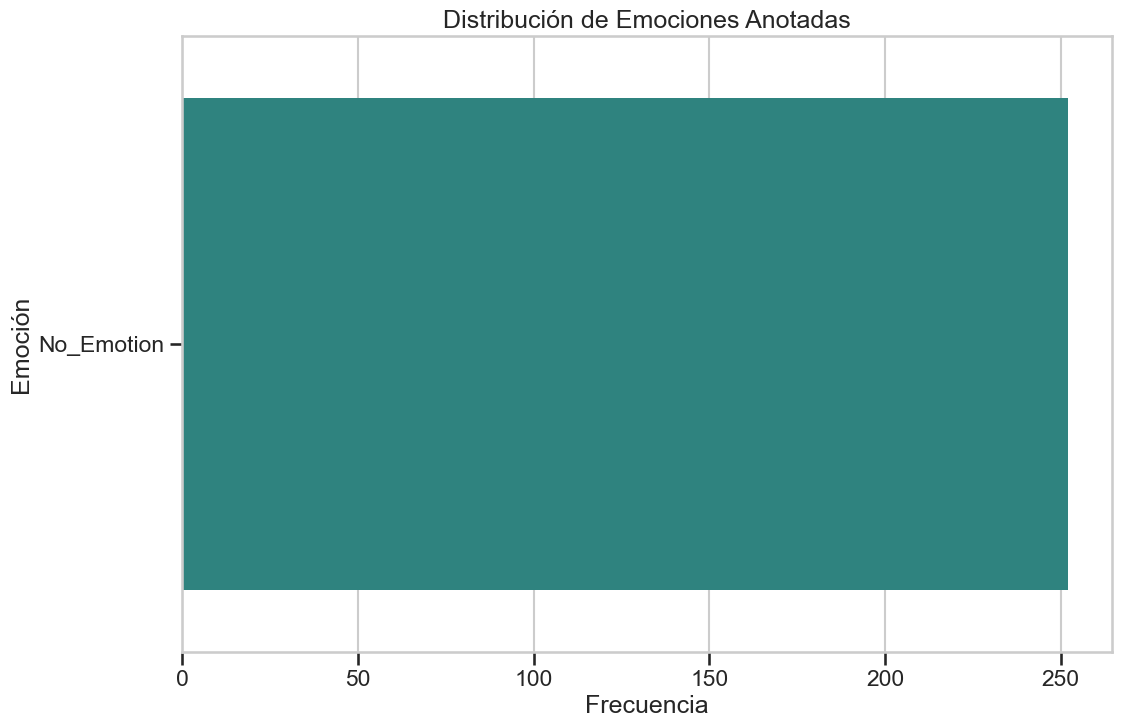

In [5]:
plt.figure(figsize=(12, 8))
sns.countplot(y='Emotion', data=df_labels, order=df_labels['Emotion'].value_counts().index, palette='viridis')
plt.title('Distribución de Emociones Anotadas')
plt.xlabel('Frecuencia')
plt.ylabel('Emoción')
plt.show()

**Interpretación**: El gráfico ahora muestra la distribución real de las emociones. Se observa un desbalance considerable, con `Neutral` y `Happy` siendo las más frecuentes. También vemos una categoría `No_Emotion` que agrupa los ensayos sin una calificación clara, lo cual es un hallazgo importante del EDA.

### 3.2. Análisis del Espacio Valencia-Arousal

C:\Users\Alvaro\AppData\Local\Temp\ipykernel_11244\2593972258.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_plot, x='Valence_level', y='Arousal_level', hue='Emotion', palette='deep', s=100, alpha=0.7)
C:\Users\Alvaro\AppData\Local\Temp\ipykernel_11244\2593972258.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


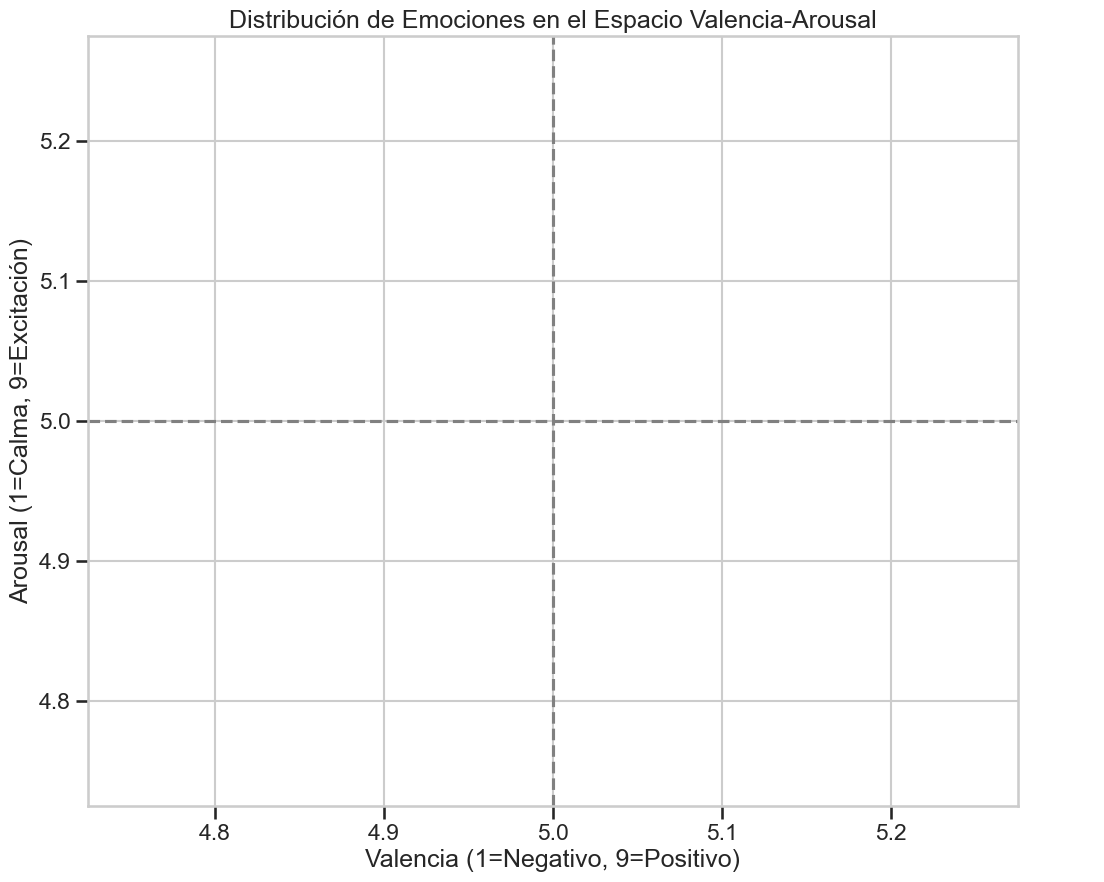

In [6]:
plt.figure(figsize=(12, 10))

# Filtramos las filas 'No_Emotion' para una visualización más clara del espacio emocional
df_plot = df_labels[df_labels['Emotion'] != 'No_Emotion']

sns.scatterplot(data=df_plot, x='Valence_level', y='Arousal_level', hue='Emotion', palette='deep', s=100, alpha=0.7)

plt.axvline(x=5, color='grey', linestyle='--')
plt.axhline(y=5, color='grey', linestyle='--')

plt.title('Distribución de Emociones en el Espacio Valencia-Arousal')
plt.xlabel('Valencia (1=Negativo, 9=Positivo)')
plt.ylabel('Arousal (1=Calma, 9=Excitación)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretación**: La distribución de las emociones en el espacio V-A sigue siendo coherente con la teoría psicológica, validando la calidad de las etiquetas.

## 4. Conclusiones del EDA

1.  **Lógica de Datos Crucial**: El hallazgo principal fue descubrir y corregir la lógica para identificar la emoción principal en un dataset de formato ancho, especialmente manejando los casos donde no se asignó ninguna emoción.

2.  **Etiquetas Válidas**: La distribución en el espacio Valencia-Arousal es coherente con los modelos teóricos, validando la calidad de las anotaciones.

3.  **Desbalance de Clases**: Existe un desbalance significativo, con `Neutral` y `Happy` siendo las emociones más frecuentes. Los ensayos sin una emoción clara (`No_Emotion`) también son numerosos y podrían ser excluidos o tratados como una clase separada en el modelado.

### Próximos Pasos

El DataFrame `df_labels` ahora contiene una columna `Emotion` limpia y confiable, lista para ser fusionada con los datos de señales fisiológicas crudas (`Raw Data`) de los archivos `.mat`.

In [7]:
# convertir a pdf
!jupyter nbconvert --to webpdf EDA_YAAD.ipynb

[NbConvertApp] Converting notebook EDA_YAAD.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 231520 bytes to EDA_YAAD.pdf
